In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
os.listdir("../data")


['database.csv', 'VEHICLE RECALL DASHBOARD.pbix']

In [3]:
df = pd.read_csv("../data/database.csv")
df.head()

,Record ID,NHTSA Campaign,Manufacturer Campaign,Vehicle Make,Vehicle Model,Model Year,Vehicle Manufacturer,Recall Type,Recall Component,Manufacture Start Date,Manufacture End Date,Estimated Units,Recall Initiative,Recall Manufacturer,Recall Notification Date
0,1,02V288000,02S41,FORD,FOCUS,2001,FORD MOTOR COMPANY,VEHICLE,ELECTRICAL SYSTEM:BATTERY:CABLES,19990719.0,20010531.0,291854.0,ODI,FORD MOTOR COMPANY,20030210.0
1,2,02V288000,02S41,FORD,FOCUS,2000,FORD MOTOR COMPANY,VEHICLE,ELECTRICAL SYSTEM:BATTERY:CABLES,19990719.0,20010531.0,291854.0,ODI,FORD MOTOR COMPANY,20030210.0
2,3,02V236000,NaN,JAYCO,FT EAGLE 10 SG,2003,"JAYCO, INC.",VEHICLE,EQUIPMENT:OTHER:LABELS,20020730.0,20020813.0,86.0,MFR,"JAYCO, INC.",20020923.0
3,4,02V237000,NaN,HOLIDAY RAMBLER,ADMIRAL SE,2003,MONACO COACH CORP.,VEHICLE,STRUCTURE,NaN,NaN,6223.0,MFR,MONACO COACH CORPORATION,20021105.0
4,5,02V237000,NaN,HOLIDAY RAMBLER,ADMIRAL SE,2002,MONACO COACH CORP.,VEHICLE,STRUCTURE,NaN,NaN,6223.0,MFR,MONACO COACH CORPORATION,20021105.0


In [4]:
df.shape

(123837, 15)

In [5]:
df.columns
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123837 entries, 0 to 123836
Data columns (total 15 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Record ID                 123837 non-null  int64  
 1   NHTSA Campaign            123837 non-null  object 
 2   Manufacturer Campaign     42290 non-null   object 
 3   Vehicle Make              123837 non-null  object 
 4   Vehicle Model             123837 non-null  object 
 5   Model Year                123837 non-null  int64  
 6   Vehicle Manufacturer      123832 non-null  object 
 7   Recall Type               123837 non-null  object 
 8   Recall Component          123837 non-null  object 
 9   Manufacture Start Date    91303 non-null   float64
 10  Manufacture End Date      91543 non-null   float64
 11  Estimated Units           123551 non-null  float64
 12  Recall Initiative         123831 non-null  object 
 13  Recall Manufacturer       123837 non-null  o

Record ID                       0
NHTSA Campaign                  0
Manufacturer Campaign       81547
Vehicle Make                    0
Vehicle Model                   0
Model Year                      0
Vehicle Manufacturer            5
Recall Type                     0
Recall Component                0
Manufacture Start Date      32534
Manufacture End Date        32294
Estimated Units               286
Recall Initiative               6
Recall Manufacturer             0
Recall Notification Date    11382
dtype: int64

In [6]:
df = df.drop(columns=["Manufacturer Campaign"])


In [7]:
df.columns

Index(['Record ID', 'NHTSA Campaign', 'Vehicle Make', 'Vehicle Model',
       'Model Year', 'Vehicle Manufacturer', 'Recall Type', 'Recall Component',
       'Manufacture Start Date', 'Manufacture End Date', 'Estimated Units',
       'Recall Initiative', 'Recall Manufacturer', 'Recall Notification Date'],
      dtype='object')

In [8]:
df["Manufacture Start Date"] = pd.to_datetime(df["Manufacture Start Date"], errors="coerce")
df["Manufacture End Date"] = pd.to_datetime(df["Manufacture End Date"], errors="coerce")
df["Recall Notification Date"] = pd.to_datetime(df["Recall Notification Date"], errors="coerce")

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123837 entries, 0 to 123836
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   Record ID                 123837 non-null  int64         
 1   NHTSA Campaign            123837 non-null  object        
 2   Vehicle Make              123837 non-null  object        
 3   Vehicle Model             123837 non-null  object        
 4   Model Year                123837 non-null  int64         
 5   Vehicle Manufacturer      123832 non-null  object        
 6   Recall Type               123837 non-null  object        
 7   Recall Component          123837 non-null  object        
 8   Manufacture Start Date    91303 non-null   datetime64[ns]
 9   Manufacture End Date      91543 non-null   datetime64[ns]
 10  Estimated Units           123551 non-null  float64       
 11  Recall Initiative         123831 non-null  object        
 12  Re

In [10]:
df = df.dropna(subset=["Vehicle Manufacturer", "Recall Initiative"])

In [11]:
df.isnull().sum()

Record ID                       0
NHTSA Campaign                  0
Vehicle Make                    0
Vehicle Model                   0
Model Year                      0
Vehicle Manufacturer            0
Recall Type                     0
Recall Component                0
Manufacture Start Date      32534
Manufacture End Date        32294
Estimated Units               286
Recall Initiative               0
Recall Manufacturer             0
Recall Notification Date    11376
dtype: int64

In [12]:
df.loc[:, "Estimated Units"] = df["Estimated Units"].fillna(df["Estimated Units"].median())

In [13]:
df["Estimated Units"].isnull().sum()

np.int64(0)

In [14]:
df["Recall Component"].value_counts().head(10)

Recall Component
EQUIPMENT:RECREATIONAL VEHICLE    6530
EQUIPMENT                         6515
EQUIPMENT ADAPTIVE                4740
EQUIPMENT:OTHER:LABELS            3749
EXTERIOR LIGHTING                 3746
SEATS                             2146
ELECTRICAL SYSTEM                 1967
VEHICLE SPEED CONTROL             1906
EXTERIOR LIGHTING:HEADLIGHTS      1789
ENGINE AND ENGINE COOLING         1722
Name: count, dtype: int64

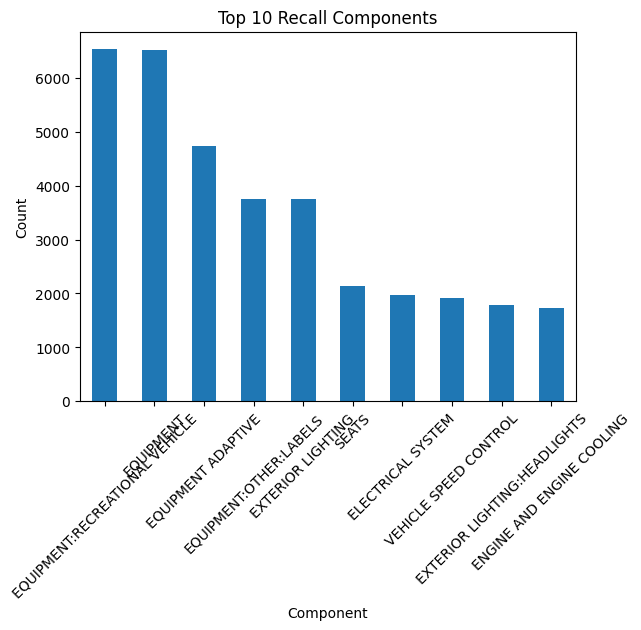

In [15]:
df["Recall Component"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Recall Components")
plt.xlabel("Component")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [16]:
df["Recall Type"].value_counts()

Recall Type
VEHICLE      107023
EQUIPMENT     13130
TIRE           2255
C               888
I               387
X               143
Name: count, dtype: int64

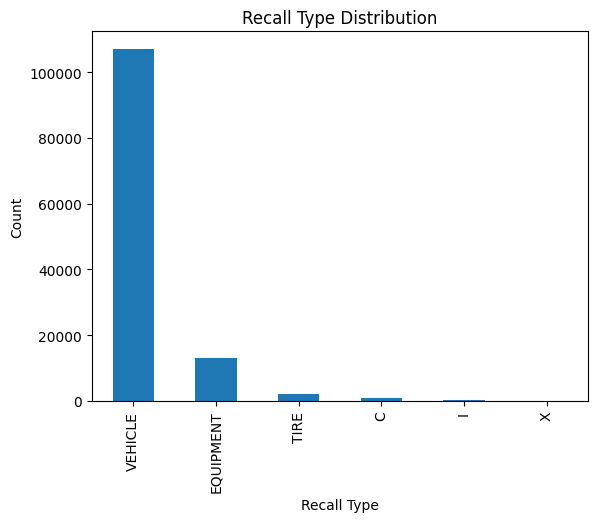

In [17]:
df["Recall Type"].value_counts().plot(kind="bar")
plt.title("Recall Type Distribution")
plt.xlabel("Recall Type")
plt.ylabel("Count")
plt.show()

In [18]:
df["Main Component"] = df["Recall Component"].str.split(":").str[0]
df["Main Component"].value_counts().head(10)

Main Component
EQUIPMENT                    20182
ELECTRICAL SYSTEM             7877
STEERING                      7802
EXTERIOR LIGHTING             7775
SERVICE BRAKES, HYDRAULIC     7232
FUEL SYSTEM, GASOLINE         6719
SUSPENSION                    6598
ENGINE AND ENGINE COOLING     6170
SERVICE BRAKES, AIR           5307
STRUCTURE                     5214
Name: count, dtype: int64

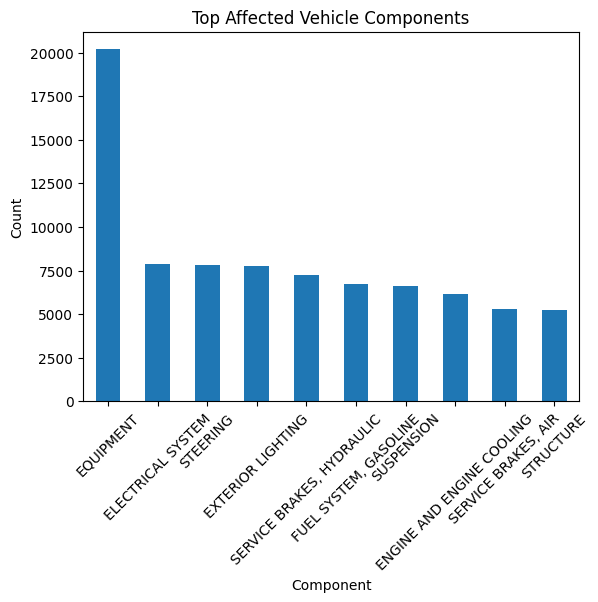

In [19]:
df["Main Component"].value_counts().head(10).plot(kind="bar")
plt.title("Top Affected Vehicle Components")
plt.xlabel("Component")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [20]:
def classify_issue(component):
    if "ELECTRICAL" in component or "SOFTWARE" in component:
        return "Software"
    else:
        return "Hardware"

df["Issue Type"] = df["Main Component"].apply(classify_issue)

In [21]:
df["Issue Type"].value_counts()

Issue Type
Hardware    115949
Software      7877
Name: count, dtype: int64

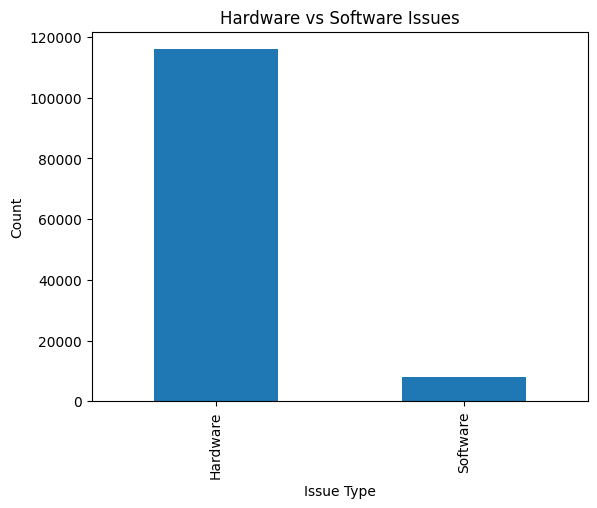

In [22]:
df["Issue Type"].value_counts().plot(kind="bar")
plt.title("Hardware vs Software Issues")
plt.xlabel("Issue Type")
plt.ylabel("Count")
plt.show()

In [23]:
df["Recall Manufacturer"].value_counts().head(10)

Recall Manufacturer
GENERAL MOTORS LLC                          10966
FORD MOTOR COMPANY                           7397
CHRYSLER (FCA US LLC)                        6102
PACCAR INCORPORATED                          3012
INTERNATIONAL TRUCK & ENGINE CORPORATION     2620
MACK TRUCKS, INC.                            2616
BMW OF NORTH AMERICA, LLC                    2316
TOYOTA MOTOR CORPORATION                     2302
FREIGHTLINER LLC                             2294
DAIMLER TRUCKS NORTH AMERICA LLC             2063
Name: count, dtype: int64

In [24]:
df["Recall Year"] = df["Recall Notification Date"].dt.year
df["Recall Year"].value_counts().sort_index()

Recall Year
1970.0    112450
Name: count, dtype: int64

In [25]:
df["Recall Notification Date"].head()

0   1970-01-01 00:00:00.020030210
1   1970-01-01 00:00:00.020030210
2   1970-01-01 00:00:00.020020923
3   1970-01-01 00:00:00.020021105
4   1970-01-01 00:00:00.020021105
Name: Recall Notification Date, dtype: datetime64[ns]

In [26]:
df["Recall Notification Date"] = pd.to_datetime(df["Recall Notification Date"], unit="ns", errors="coerce")

In [27]:
df["Recall Year"] = df["Recall Notification Date"].dt.year
df["Recall Year"].value_counts().sort_index()

Recall Year
1970.0    112450
Name: count, dtype: int64

In [28]:
pd.crosstab(df["Recall Manufacturer"], df["Main Component"]).head(10)

Main Component,AIR BAGS,BACK OVER PREVENTION,CHILD SEAT,COMMUNICATIONS,ELECTRICAL SYSTEM,ELECTRONIC STABILITY CONTROL,ENGINE,ENGINE AND ENGINE COOLING,EQUIPMENT,EQUIPMENT ADAPTIVE,...,SUSPENSION,TBD,TIRES,TRACTION CONTROL SYSTEM,TRAILER HITCHES,UNKNOWN OR OTHER,VEHICLE SPEED CONTROL,VISIBILITY,VISIBILITY/WIPER,WHEELS
Recall Manufacturer,,,,,,,,,,,,,,,,,,,,,
1888653 ONTARIO INC,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3M COMPANY TRAFFIC SAFETY SYSTEMS DIV.,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
"4-STAR TRAILERS, INC",0,0,0,0,0,0,0,0,12,0,...,0,0,0,0,0,0,0,0,0,0
"A&M SYSTEMS, INC.",0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
A. GIRARDIN INC.,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
"AAI MOTORSPORTS USA, LLC",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ABADDON PRODUCTS CO.,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
"ABC ENGINEERING, CO",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,12,0,0
ACCESS MOBILITY CENTER,0,0,0,0,0,0,0,0,0,2,...,0,0,0,0,0,0,0,0,0,0


In [29]:
top_manu = df["Recall Manufacturer"].value_counts().head(10).index

In [30]:
pd.crosstab(
    df[df["Recall Manufacturer"].isin(top_manu)]["Recall Manufacturer"],
    df["Main Component"]
)

Main Component,AIR BAGS,CHILD SEAT,COMMUNICATIONS,ELECTRICAL SYSTEM,ELECTRONIC STABILITY CONTROL,ENGINE,ENGINE AND ENGINE COOLING,EQUIPMENT,EQUIPMENT ADAPTIVE,EXTERIOR LIGHTING,...,STRUCTURE,SUSPENSION,TIRES,TRACTION CONTROL SYSTEM,TRAILER HITCHES,UNKNOWN OR OTHER,VEHICLE SPEED CONTROL,VISIBILITY,VISIBILITY/WIPER,WHEELS
Recall Manufacturer,,,,,,,,,,,,,,,,,,,,,
"BMW OF NORTH AMERICA, LLC",384,15,0,157,1,2,421,26,0,262,...,30,70,27,0,0,1,89,43,0,73
CHRYSLER (FCA US LLC),497,47,0,362,9,4,159,298,7,436,...,228,501,51,0,15,33,162,203,0,81
DAIMLER TRUCKS NORTH AMERICA LLC,4,0,0,135,41,0,529,131,157,41,...,220,43,7,0,20,0,28,9,0,2
FORD MOTOR COMPANY,226,5,0,310,3,7,374,361,425,688,...,196,263,147,0,16,7,692,156,0,144
FREIGHTLINER LLC,1,0,0,83,1,0,129,69,85,119,...,106,167,10,0,76,1,66,38,0,32
GENERAL MOTORS LLC,520,22,5,684,27,0,441,1091,79,875,...,260,442,46,0,28,13,320,312,0,280
INTERNATIONAL TRUCK & ENGINE CORPORATION,0,0,0,33,0,0,64,69,0,121,...,8,155,65,0,18,2,96,22,0,163
"MACK TRUCKS, INC.",0,0,18,101,0,2,236,0,0,121,...,21,339,2,0,74,10,142,31,0,50
PACCAR INCORPORATED,42,0,0,353,1,0,281,276,0,130,...,16,250,191,0,101,22,55,110,0,15


In [31]:
df["Vehicle Make"].value_counts().head(10)

Vehicle Make
FORD                       6348
CHEVROLET                  4669
DODGE                      2996
GMC                        2821
MACK                       2600
FREIGHTLINER               2426
INTERNATIONAL HARVESTER    2323
BMW                        2201
BLUE BIRD                  1964
VOLVO                      1827
Name: count, dtype: int64

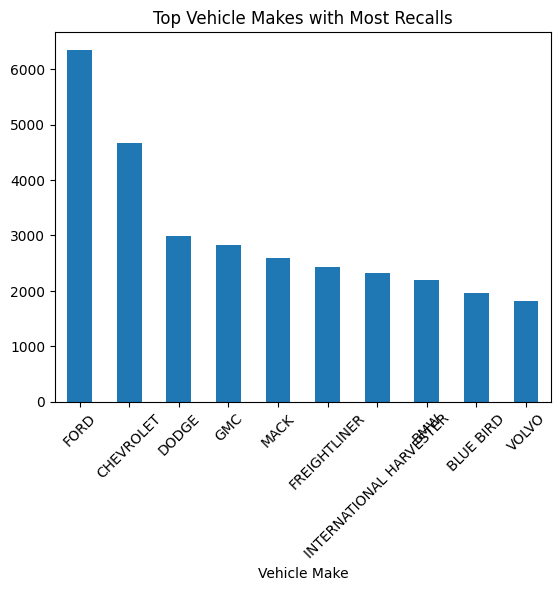

In [32]:
df["Vehicle Make"].value_counts().head(10).plot(kind="bar")
plt.title("Top Vehicle Makes with Most Recalls")
plt.xticks(rotation=45)
plt.show()

In [33]:
df["Model Year"].value_counts().head(10)

Model Year
9999    7845
2007    5112
2008    5036
2006    5013
2009    4562
2005    4296
2010    4273
2011    4268
2004    4236
2003    4164
Name: count, dtype: int64

In [34]:
df = df[df["Model Year"] != 9999]

In [35]:
df["Model Year"].value_counts().head(10)

Model Year
2007    5112
2008    5036
2006    5013
2009    4562
2005    4296
2010    4273
2011    4268
2004    4236
2003    4164
2000    3977
Name: count, dtype: int64

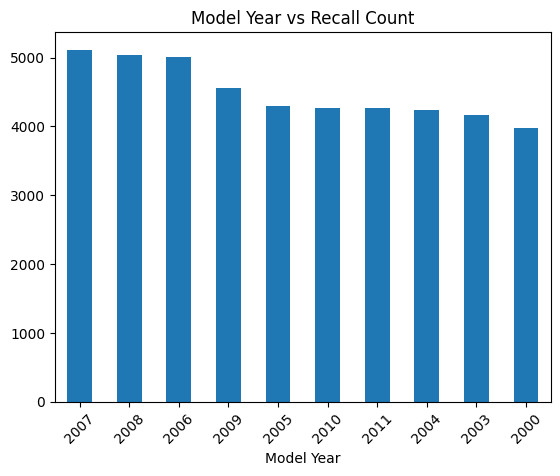

In [36]:
df["Model Year"].value_counts().head(10).plot(kind="bar")
plt.title("Model Year vs Recall Count")
plt.xticks(rotation=45)
plt.show()

In [37]:
df.groupby("Recall Type")["Estimated Units"].sum().sort_values(ascending=False)

Recall Type
VEHICLE      1.474334e+10
X            7.701115e+08
TIRE         5.777405e+08
EQUIPMENT    3.717876e+08
I            2.216323e+08
C            9.630344e+07
Name: Estimated Units, dtype: float64

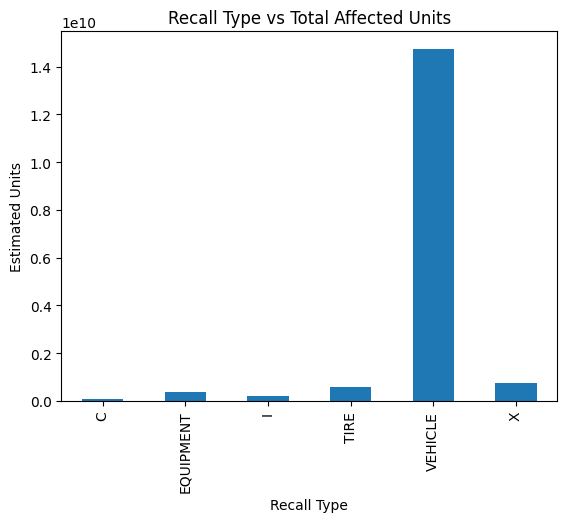

In [38]:
df.groupby("Recall Type")["Estimated Units"].sum().plot(kind="bar")
plt.title("Recall Type vs Total Affected Units")
plt.ylabel("Estimated Units")
plt.show()

In [39]:
df.groupby("Main Component")["Estimated Units"].sum().sort_values(ascending=False).head(10)

Main Component
AIR BAGS                     3.244052e+09
VEHICLE SPEED CONTROL        1.740327e+09
ELECTRICAL SYSTEM            1.571638e+09
POWER TRAIN                  1.521461e+09
TIRES                        1.383915e+09
ENGINE AND ENGINE COOLING    1.000134e+09
SEAT BELTS                   9.251723e+08
FUEL SYSTEM, GASOLINE        8.354393e+08
SERVICE BRAKES, HYDRAULIC    7.056091e+08
STRUCTURE                    6.064561e+08
Name: Estimated Units, dtype: float64

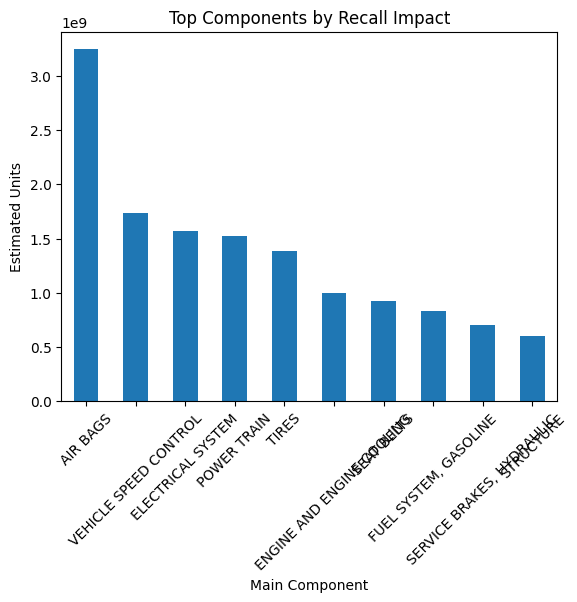

In [40]:
df.groupby("Main Component")["Estimated Units"].sum().sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top Components by Recall Impact")
plt.ylabel("Estimated Units")
plt.xticks(rotation=45)
plt.show()

In [41]:
df.groupby("Recall Manufacturer")["Estimated Units"].mean().sort_values(ascending=False).head(10)

Recall Manufacturer
CENTURY PRODUCTS                    2.361146e+06
GANEAUX INDUSTRIES                  1.350000e+06
EVENFLO COMPANY, INC.               1.000000e+06
DOREL JUVENILE GROUP                7.019332e+05
FORD MOTOR COMPANY                  6.660026e+05
HONDA (AMERICAN HONDA MOTOR CO.)    6.217398e+05
MAZDA NORTH AMERICAN OPERATIONS     5.805821e+05
GENERAL MOTORS LLC                  4.417127e+05
MAZDA MOTOR CORP.                   4.114796e+05
HYUNDAI MOTOR AMERICA               4.074027e+05
Name: Estimated Units, dtype: float64

In [42]:
df.to_csv("cleaned_vehicle_recall_data.csv", index=False)